In [7]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import ttest_ind
from natsort import natsorted
from sklearn.decomposition import PCA
import nibabel.freesurfer.io as fsio
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
import glob
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os
from scipy.stats import linregress
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind
from sklearn.metrics import pairwise_distances
import seaborn as sns
import nibabel as nib
from collections import Counter
from nibabel import cifti2
from scipy.spatial import procrustes
from scipy.stats import ttest_ind
np.random.seed(42)

In [8]:
geodesicA1 = pd.read_csv('../Derivatives/human_A1_schaefer.csv')
geodesicA1 = geodesicA1[geodesicA1['Index']!=0].dist.values
geodesicV1 = pd.read_csv('../Derivatives/human_V1_schaefer.csv')
geodesicV1 = geodesicV1[geodesicV1['Index']!=0].dist.values

In [9]:
blind_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_rh_Schaefer2Schaefer.npy')
blind_MMP_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/blindsource_blindtarget_individual_fingerprint_fc_lh_Schaefer2Schaefer.npy')
control_MMP_rh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_rh_Schaefer2Schaefer.npy')
control_MMP_lh = np.load('../Dataset/fingerprint_FC_dataset/result_blinddeaf/controlsource_controltarget_individual_fingerprint_fc_lh_Schaefer2Schaefer.npy')

In [10]:
region_label = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 9, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 9, 9, 7, 9, 7, 9, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 9, 9, 8, 8,
       8, 8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 9, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 4, 9, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 9, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 9, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 9,
       7, 9, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 9, 9, 9, 8, 8, 8,
       8, 8, 8, 8]

network_names = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default', 'TempPar', 'Auditory']
labels = [f"{i}_{j}" for i in network_names for j in network_names]

In [11]:
def compute_roi_connectivity(data, region_label, MMPname, roi_name):
    subject_data = []
    roi_cols = [i for i, name in enumerate(MMPname[200:]) if name==roi_name]
    
    for subj in data:
        z_corr = np.tanh(subj)  # Fisher z
        df = pd.DataFrame(z_corr)
        df.index = region_label[200:]
        df.columns = MMPname[200:]
        
        roi_df = df.iloc[:, roi_cols]
        avg_conn = roi_df.mean(axis=1).values  # mean across ROI columns for each region
        subject_data.append(avg_conn)

    return pd.DataFrame(subject_data, columns=region_label[200:])

In [12]:
SA = pd.read_csv('../Dataset/Sensorimotor_Association_Axis_AverageRanks.csv')

In [13]:
labels, ctab, names = nib.freesurfer.read_annot('../Dataset/template/rh.HCPMMP1.annot')
roi_names = [name.decode('utf-8') for name in names]
MMPname = roi_names[1:]
lut = pd.DataFrame(MMPname)
auditory_rois = [
    "R_A1_ROI","R_MBelt_ROI","R_LBelt_ROI","R_PBelt_ROI",
    "R_TA2_ROI","R_STGa_ROI","R_STSva_ROI","R_PI_ROI","R_RI_ROI"
]
auditory_ids = lut[lut[0].isin(auditory_rois)].index.values + 1
auditory_regionid = [i+1 for i in np.arange(len(MMPname)) if MMPname[i] in ["R_A1_ROI","R_MBelt_ROI","R_LBelt_ROI","R_PBelt_ROI","R_STGa_ROI","R_STSva_ROI"]] #]]  #, ,"R_STGa_ROI""R_TA2_ROI" ,"R_STSva_ROI","R_PI_ROI","R_RI_ROI"

In [14]:
def region_to_name(region_id, regions):
    """
    Convert region ID (1-based) to region name using `regions` list.
    Returns None if region_id is out of range.
    """
    return regions[region_id - 1]

In [15]:
regions = ['TE 1.0', 'TE 2.1', 'TE 1.2', 'TE 3', 'TE 1.1','TE 2.2', 'STS1', 'STS2', 'TE 1.0', 'TE 2.1', 'TE 1.2', 'TE 3', 'TE 1.1','TE 2.2', 'STS1', 'STS2']
streams = {
    'A1': ['TE 1.0','TE 1.1', 'TE 1.2'],
    'A2': ['TE 2.1','TE 2.2'],
    'A3': ['TE 3'], #
    'STS': ['STS1', 'STS2']
}

In [16]:
stream_labels = []
unique_labels = set()
#with open("../derivatives/all_schaefer_overlaps.txt", "r") as f:
with open("../Derivatives/auditory_Julich_schaefer_overlaps.txt", "r") as f:
    for t, line in enumerate(f):
        # Split by ':' and then spaces, skip empty strings
        parts = line.strip().split(":")
        print(parts[0])
        region_name = region_to_name(t+1, regions)
        region_stream = None
        print(region_name)
        if region_name is not None:
            for stream, r in streams.items():
                if region_name in r:
                    region_stream = stream
                    break
        stream_labels.append(region_stream)
        #if int(parts[0]) in auditory_regionid:
        if len(parts) > 1:
            numbers = parts[1].strip().split()
            unique_labels.update(map(int, numbers))
unique_labels = [i-1 for i in unique_labels if i!=0 ]
auditory = [1 if i in unique_labels else 0 for i in np.arange(400)]
parcel_to_stream = {}
with open("../Derivatives/auditory_Julich_schaefer_overlaps.txt", "r") as f:
    for t,line in enumerate(f):
        parts = line.strip().split(":")
        regionid = int(parts[0])

        # region → name
        region_name = region_to_name(t+1, regions)

        # region → stream
        region_stream = None
        if region_name is not None:
            for stream, r in streams.items():
                if region_name in r:
                    region_stream = stream
                    break

        # region → parcels
        if len(parts) > 1:
            parcels = [int(p) for p in parts[1].split() if int(p) != 0]

            for parcel_id in parcels:
                # optional: convert to 0-based indexing
                parcel_to_stream[parcel_id - 1] = region_stream
stream_list = [parcel_to_stream[pid] for pid in unique_labels]
auditory_stream_by_parcel = [
    parcel_to_stream.get(pid, None)
    for pid in np.arange(400)
]

11
TE 1.0
12
TE 2.1
14
TE 1.2
15
TE 3
16
TE 1.1
17
TE 2.2
93
STS1
94
STS2
1011
TE 1.0
1012
TE 2.1
1014
TE 1.2
1015
TE 3
1016
TE 1.1
1017
TE 2.2
1093
STS1
1094
STS2


In [17]:
regions = [x.split(' - ')[1] for x in pd.read_csv('../Dataset/template/Wang/ROIfiles_Labeling.txt', sep='\t').index.values] + [x.split(' - ')[1] for x in pd.read_csv('/mnt/DataDrive3/NishioM/Blind/template/Wang/ROIfiles_Labeling.txt', sep='\t').index.values]
regionid = [i+1 for i in np.arange(len(regions)) if regions[i] in ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'VO1', 'PHC1']] #,'LO2' ''PHC2',IPS2', , 'LO1']'IPS3','VO2', 'IPS4', 'SPL1', 'FEF']] #['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'VO1', 'VO2', 'PHC1', 'PHC2', 'LO1', 'LO2']

In [18]:
streams = {
    'Primary': ['V1v','V1d','V2v','V2d','V3v','V3d','hV4'],
    'Ventral': ['VO1','VO2','PHC2','PHC1'],
    'Lateral': ['LO1','LO2','hMT','MST'],
    'Dorsal': ['V3a','V3b','IPS0','IPS1','IPS2','IPS3','IPS4','IPS5','SPL1']
}

In [19]:
stream_labels = []
unique_labels = set()
with open("../Derivatives/wang_schaefer_overlaps.txt", "r") as f:
    for line in f:
        # Split by ':' and then spaces, skip empty strings
        parts = line.strip().split(":")
        regionid = int(parts[0])
        print(regionid)
        region_name = region_to_name(regionid, regions)
        region_stream = None
        print(region_name)
        if region_name is not None:
            for stream, r in streams.items():
                if region_name in r:
                    region_stream = stream
                    break
        stream_labels.append(region_stream)
        #if int(parts[0]) in regionid:
        if len(parts) > 1:
            numbers = parts[1].strip().split()
            unique_labels.update(map(int, numbers))
unique_labels = [i-1 for i in unique_labels if i!=0 ]
visual = [1 if i in unique_labels else 0 for i in np.arange(400)]

1
V1v
2
V1d
3
V2v
4
V2d
5
V3v
6
V3d
7
hV4
8
VO1
9
VO2
10
PHC1
11
PHC2
12
MST
13
hMT
14
LO2
15
LO1
16
V3b
17
V3a
18
IPS0
19
IPS1
20
IPS2
21
IPS3
22
IPS4
23
IPS5
24
SPL1
25
FEF
26
V1v
27
V1d
28
V2v
29
V2d
30
V3v
31
V3d
32
hV4
33
VO1
34
VO2
35
PHC1
36
PHC2
37
MST
38
hMT
39
LO2
40
LO1
41
V3b
42
V3a
43
IPS0
44
IPS1
45
IPS2
46
IPS3
47
IPS4
48
IPS5
49
SPL1
50
FEF


In [20]:
sum(visual)

86

In [21]:
parcel_to_stream = {}

with open("../Derivatives/wang_schaefer_overlaps.txt", "r") as f:
    for line in f:
        parts = line.strip().split(":")
        regionid = int(parts[0])

        # region → name
        region_name = region_to_name(regionid, regions)

        # region → stream
        region_stream = None
        if region_name is not None:
            for stream, r in streams.items():
                if region_name in r:
                    region_stream = stream
                    break

        # region → parcels
        if len(parts) > 1:
            parcels = [int(p) for p in parts[1].split() if int(p) != 0]

            for parcel_id in parcels:
                # optional: convert to 0-based indexing
                parcel_to_stream[parcel_id - 1] = region_stream
stream_list = [parcel_to_stream[pid] for pid in unique_labels]


In [22]:
visual_stream_by_parcel = [
    parcel_to_stream.get(pid, None)
    for pid in np.arange(400)
]

In [23]:
all_dfs = {}
for roi in np.arange(1,10):
    blind_df = compute_roi_connectivity(blind_MMP_rh, region_label, region_label, roi)
    control_df = compute_roi_connectivity(control_MMP_rh, region_label, region_label, roi)
    
    # Add group labels
    blind_df['group'] = 'blind'
    control_df['group'] = 'control'
    
    # Combine groups
    full_df = pd.concat([blind_df, control_df], ignore_index=True)
    
    # Save
    all_dfs[roi] = full_df

In [24]:
parcel_data = []
for roi, df in all_dfs.items():
    df_copy = df.copy()
    df_copy['ROI'] = roi
    parcel_data.append(df_copy)
raw_df = pd.concat(parcel_data, ignore_index=True)

In [25]:
t_all = []
p_all = []
for roi in raw_df['ROI'].unique():
    roi_df = raw_df[raw_df['ROI'] == roi]
    features = roi_df.drop(columns=['group', 'ROI'])
    t = []
    p = []
    for i in np.arange(200):
        blind_vals = roi_df[roi_df['group'] == 'blind'].iloc[:, i].values
        control_vals = roi_df[roi_df['group'] == 'control'].iloc[:, i].values
        t_stat, p_val = ttest_ind(blind_vals, control_vals, nan_policy='omit')
        t.append(t_stat)
        #t.append(np.mean(blind_vals)-np.mean(control_vals))
        p.append(p_val)
    t_all.append(t)
    p_all.append(p)

In [26]:
ttest_df = pd.DataFrame(t_all).T
ttest_df.columns = raw_df['ROI'].unique()
pvalue_df = pd.DataFrame(p_all).T
pvalue_df.columns = raw_df['ROI'].unique()

In [27]:
ttest_df['SA'] = SA['finalrank.hemisphere'][200:].values
ttest_df['A1'] = geodesicA1[200:] #rh_auditory
ttest_df['V1'] = geodesicV1[200:] #rh_auditory
ttest_df['network'] = region_label[200:]
ttest_df['auditory'] = auditory[200:]
ttest_df['visual'] = visual[200:]
ttest_df['stream'] = visual_stream_by_parcel[200:]

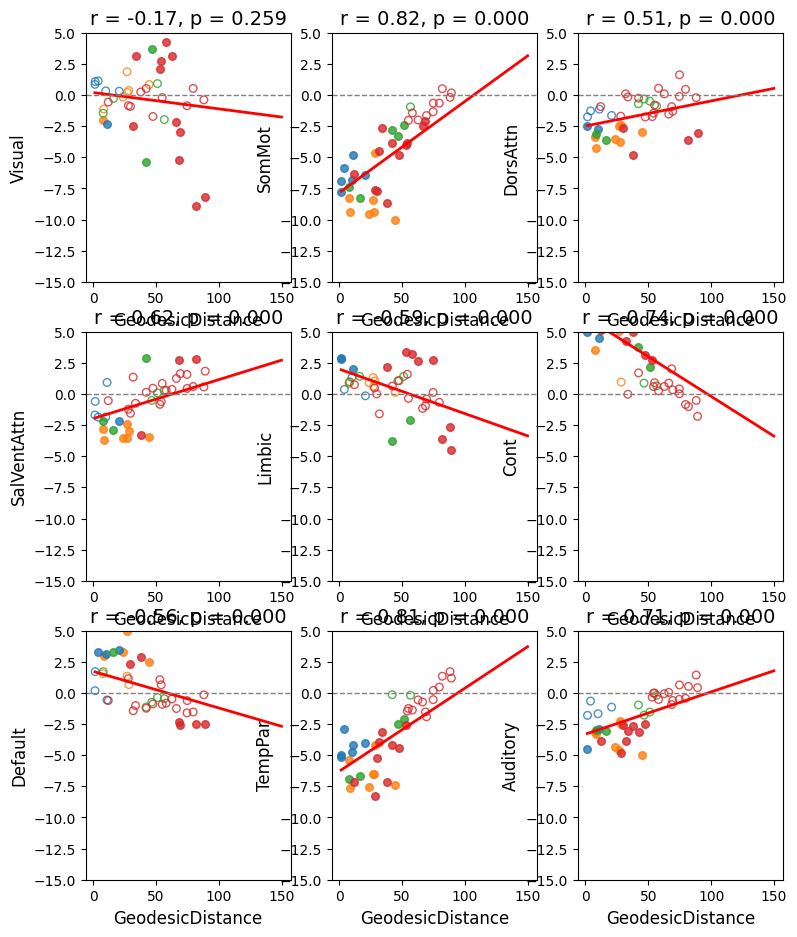

In [32]:
# Filter visual parcels
ttest_df = ttest_df[ttest_df.visual == 1]

# Define markers and colors per stream
STREAM_MARKERS = {
    'Primary': 'o',
    'Ventral': 'o',
    'Lateral': 'o',
    'Dorsal': 'o',
    None: 'o'#xD^s
}

STREAM_COLORS = {
    'Primary': 'tab:blue',
    'Ventral': 'tab:orange',
    'Lateral': 'tab:green',
    'Dorsal': 'tab:red',
    None: 'gray'
}

fig, axs = plt.subplots(3, 3, figsize=(9, 11))

for i, ax in enumerate(axs.flatten()):
    x = ttest_df['V1']
    y = ttest_df.iloc[:, i]
    r, p = pearsonr(x, y)

    # Fit regression line
    slope, intercept = np.polyfit(x, y, 1)
    x_vals = np.array([x.min(), x.max()])
    y_vals = intercept + slope * x_vals
    ax.plot(x_vals, y_vals, color='red', lw=2)

    # Get p-values for current column
    pvals = pvalue_df.iloc[:, i]

    # Masks for significance
    sig_mask = pvals < 0.05
    nonsig_mask = ~sig_mask

    # Scatter points by stream
    streams = ttest_df['stream']
    for stream in streams.unique():
        stream_mask = streams == stream

        # Significant: filled
        mask_sig = stream_mask & sig_mask
        ax.scatter(
            x[mask_sig],
            y[mask_sig],
            marker=STREAM_MARKERS.get(stream, 'o'),
            color=STREAM_COLORS.get(stream, 'gray'),
            alpha=0.8,
            s=30,
            label=f'{stream} (p<0.05)'
        )

        # Non-significant: hollow
        mask_ns = stream_mask & nonsig_mask
        ax.scatter(
            x[mask_ns],
            y[mask_ns],
            marker=STREAM_MARKERS.get(stream, 'o'),
            facecolors='none',
            edgecolors=STREAM_COLORS.get(stream, 'gray'),
            alpha=0.8,
            s=30,
            label=f'{stream} (n.s.)'
        )

    # Axes settings
    ax.set_ylim([-15, 5])
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('GeodesicDistance', size=12)
    ax.set_ylabel(network_names[i], size=12)
    ax.set_title(f'r = {r:.2f}, p = {p:.3f}', size=14)

    # Clean legend: avoid duplicates
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    #ax.legend(by_label.values(), by_label.keys(), fontsize=10)

plt.show()
